In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

plt.rcParams['image.cmap'] = 'gray'

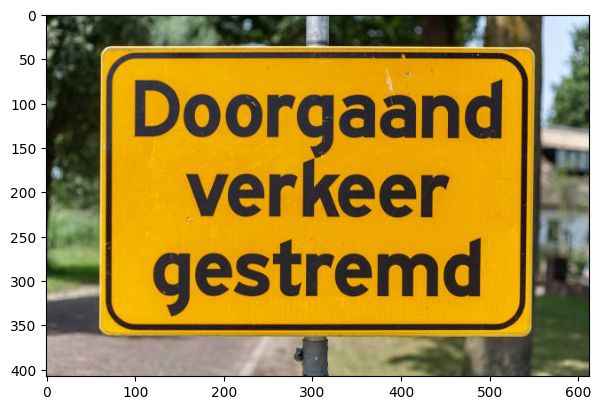

In [2]:
image = cv2.imread('../visuals/dutch_signboard.jpg')

plt.figure(figsize=(7,5))
plt.imshow(image[:,:,::-1])
plt.show()

In [3]:
vocabulary = []

with open('../resources/alphabet_94.txt') as f:
    for l in f:
        vocabulary.append(l.strip())

print("Vocabulary Size ", len(vocabulary))
print("Vocabulary :", vocabulary)


Vocabulary Size  94
Vocabulary : ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', ':', ';', '<', '=', '>', '?', '@', '[', '\\', ']', '^', '_', '`', '{', '|', '}', '~']


In [4]:
textDetector = cv2.dnn_TextDetectionModel_DB("../resources/DB_TD500_resnet50.onnx")

inputSize = (640, 640)

binThresh = 0.3
polyThresh = 0.5

mean = (122.67891434, 116.66876762, 104.00698793)

textDetector.setBinaryThreshold(binThresh).setPolygonThreshold(polyThresh)
textDetector.setInputParams(1.0/255, inputSize, mean, True)

In [5]:
textRecognizer = cv2.dnn_TextRecognitionModel("../resources/crnn_cs.onnx")
textRecognizer.setDecodeType("CTC-greedy")
textRecognizer.setVocabulary(vocabulary)
textRecognizer.setInputParams(1/127.5, (100,32), (127.5, 127.5, 127.5), True)

In [6]:
boxes, confs = textDetector.detect(image)

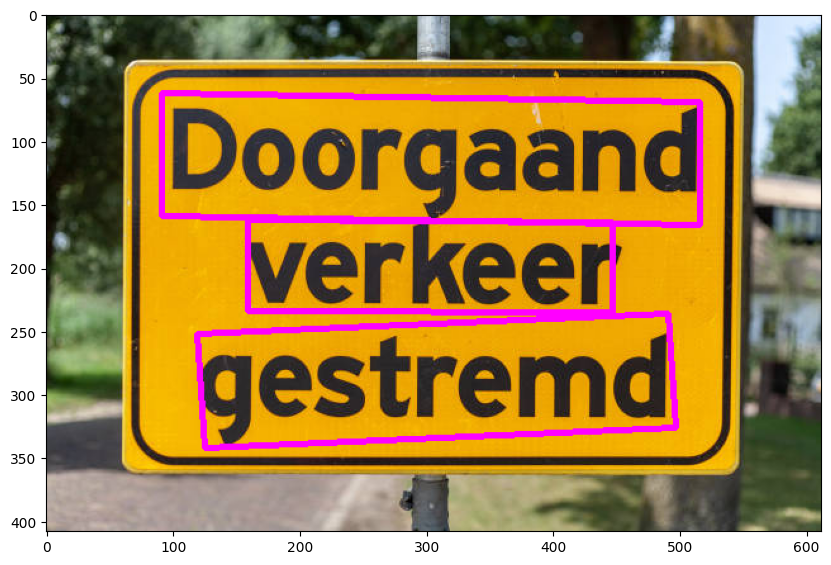

In [7]:
cv2.polylines(image, boxes, True, (255, 0, 255), 4)
plt.figure(figsize=(10,8))
plt.imshow(image[...,::-1])
plt.show()

In [9]:
def fourPointTransform(frame, vertices):
    vertices = np.asarray(vertices).astype(np.float32)
    outputSize = (100, 32)
    targetVertices = np.array([
        [0,outputSize[1]],
        [0,0],
        [outputSize[0] - 1, 0],
        [outputSize[0] - 1, outputSize[1] - 1]
    ], dtype='float32')
    rotationMatrix = cv2.getPerspectiveTransform(vertices, targetVertices)
    result = cv2.warpPerspective(frame, rotationMatrix, outputSize)
    return result

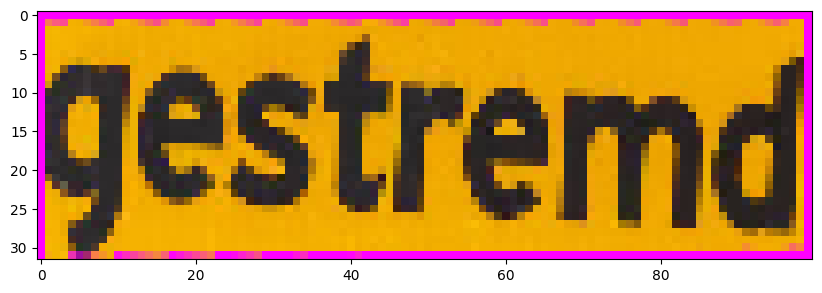

In [10]:
warped_detection = fourPointTransform(image, boxes[0])
plt.figure(figsize=(10,9))
plt.imshow(warped_detection[..., ::-1])
plt.show()

Recognized Text
gestremdverkeerDoorgaand


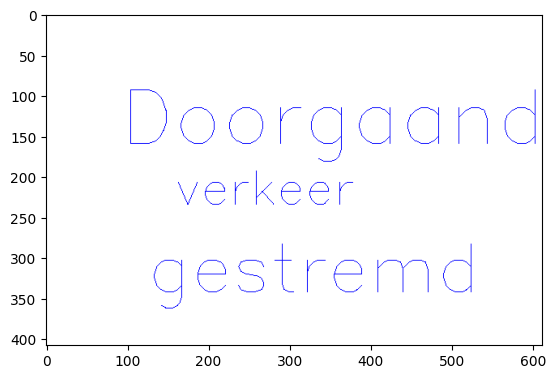

In [15]:
textData = []

output_canvas = np.full(image.shape[:3], 255, dtype = np.uint8)

print("Recognized Text")

for box in boxes:
    croppedROI = fourPointTransform(image, box)

    recResult = textRecognizer.recognize(croppedROI)

    boxHeight = int((abs((box[0,1] - box[1,1]))))

    fontScale = cv2.getFontScaleFromHeight(cv2.FONT_HERSHEY_SIMPLEX, boxHeight - 30, 1)

    placement = (int(box[0,0]), int(box[0,1]))

    cv2.putText(output_canvas, recResult, placement, cv2.FONT_HERSHEY_SIMPLEX, fontScale, (255,0,0), 1, 5)

    textData.append(recResult)

textData = ''.join(textData)
print(textData)
plt.imshow(output_canvas[...,::-1])
plt.show()

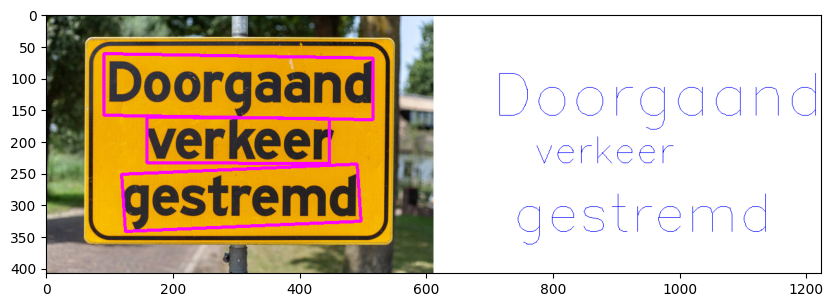

In [16]:
#Concat Input and Output
output = cv2.hconcat([image, output_canvas])
cv2.imwrite("OuputCanvas_image.jpg", output)
plt.figure(figsize=(10,8))
plt.imshow(output[...,::-1])
plt.show()

In [22]:
def recognizeText(image,debug=False):
    output_canvas = np.full(image.shape[:3], 255, np.uint8)
    boxes, confs = textDetector.detect(image)

    print("Recognized Text")

    for box in boxes:
        croppedROI = fourPointTransform(image, box)

        if debug:
            plt.imshow(croppedROI)
            plt.show()

        recResult = textRecognizer.recognize(croppedROI)
        print(recResult)

        boxHeight = int((abs((box[0, 1] - box[1, 1]))))

        fontScale = cv2.getFontScaleFromHeight(cv2.FONT_HERSHEY_SIMPLEX, boxHeight - 10, 1)
        placement = (int(box[0,0]) , int(box[0,1]))
        cv2.putText(output_canvas, recResult, placement, cv2.FONT_HERSHEY_SIMPLEX, fontScale, (255, 0, 0), 1, 5)

    cv2.polylines(image, boxes, True, (255, 0, 255), 4)
    combinedResult = cv2.hconcat([image, output_canvas])

    plt.figure(figsize=(10,8))
    plt.imshow(combinedResult[...,::-1])
    plt.title("Output Image")
    

Recognized Text
SELFISH
ISN'T
CARE
SELF


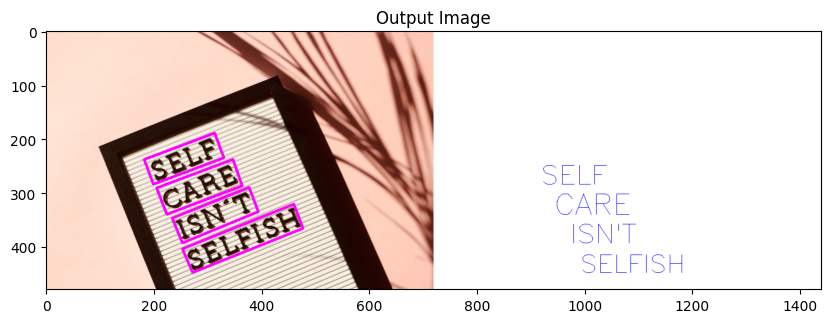

In [23]:
img2 = cv2.imread('../visuals/card.jpg')
recognizeText(img2)

Recognized Text


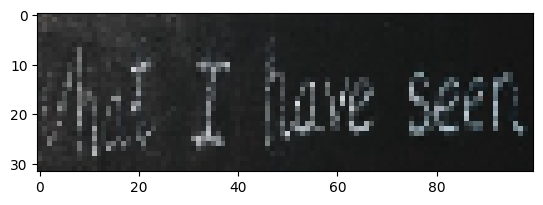

AATAweSE


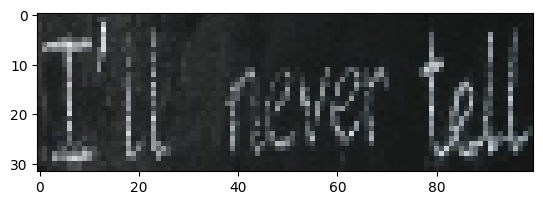

Iinvertell


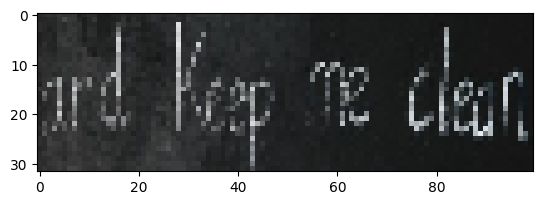

udkepedn


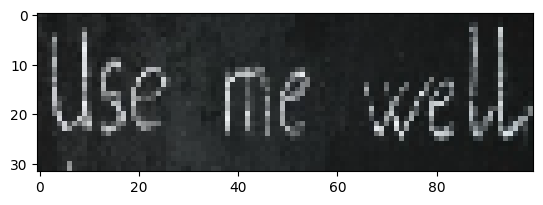

Use-metwell


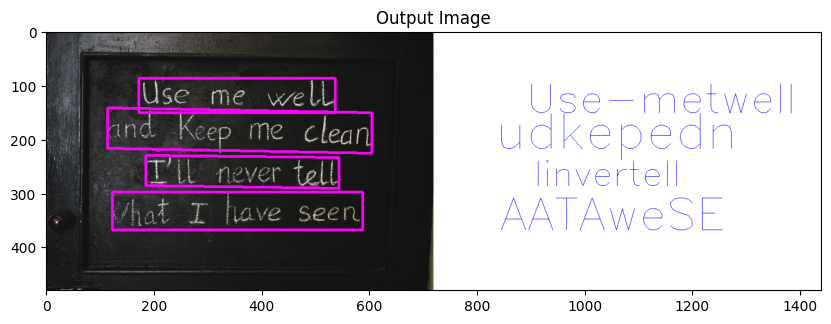

In [24]:
img6 = cv2.imread('../visuals/Board.jpg')
recognizeText(img6, debug = True)